In [22]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score
)

pd.set_option("display.max_columns", None)
sns.set_context("notebook")

RANDOM_STATE = 42


## Task 1 - Data Acquisition and Exploration

### 1.1 Load the Breast Cancer Wisconsin (Diagnostic) Dataset

In [23]:

# The Breast Cancer Wisconsin (Diagnostic) dataset is available directly
# through scikit-learn and is the same diagnostic dataset used for binary
# benign/malignant classification.

cancer = load_breast_cancer()

X = pd.DataFrame(cancer.data, columns=cancer.feature_names)

# sklearn target:
# 0 = malignant, 1 = benign
# We reverse it so:
# Outcome 1 = malignant, Outcome 0 = benign
y = pd.Series((cancer.target == 0).astype(int), name="Outcome")

df = X.copy()
df["Outcome"] = y

print("Dataset shape:", df.shape)
print("Number of features:", X.shape[1])
print("\nFirst 5 rows:")
display(df.head())


Dataset shape: (569, 31)
Number of features: 30

First 5 rows:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,Outcome
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,1
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,1
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,1
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,1
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,1



### Dataset Description
The dataset contains measurements computed from digitized images of breast-mass fine-needle aspirates.  
The task is binary classification between **benign** and **malignant** tumors.


### 1.2 Summary Statistics

In [24]:

feature_cols = [col for col in df.columns if col != "Outcome"]

summary_stats = pd.DataFrame({
    "Mean": df[feature_cols].mean(),
    "Median": df[feature_cols].median(),
    "Std Dev": df[feature_cols].std(),
    "Minimum": df[feature_cols].min(),
    "Maximum": df[feature_cols].max()
})

display(summary_stats.round(4))


,Mean,Median,Std Dev,Minimum,Maximum
mean radius,14.1273,13.3700,3.5240,6.9810,28.1100
mean texture,19.2896,18.8400,4.3010,9.7100,39.2800
mean perimeter,91.9690,86.2400,24.2990,43.7900,188.5000
mean area,654.8891,551.1000,351.9141,143.5000,2501.0000
mean smoothness,0.0964,0.0959,0.0141,0.0526,0.1634
mean compactness,0.1043,0.0926,0.0528,0.0194,0.3454
mean concavity,0.0888,0.0615,0.0797,0.0000,0.4268
mean concave points,0.0489,0.0335,0.0388,0.0000,0.2012
mean symmetry,0.1812,0.1792,0.0274,0.1060,0.3040
mean fractal dimension,0.0628,0.0615,0.0071,0.0500,0.0974



**Interpretation:**  
The features are measured on very different numerical scales. For example, area-related variables have much larger values than smoothness- or symmetry-related variables. This is one reason why feature standardization is important before logistic regression.


### 1.3 Check and Handle Missing Values and Duplicates

In [25]:

missing_per_column = df.isnull().sum()
total_missing = missing_per_column.sum()
duplicate_count = df.duplicated().sum()

print("Total missing values:", total_missing)
print("Duplicate rows:", duplicate_count)

if total_missing > 0:
    print("\nColumns containing missing values:")
    display(missing_per_column[missing_per_column > 0])

# Handle missing values, if any, using the feature median.
for col in feature_cols:
    if df[col].isnull().any():
        df[col] = df[col].fillna(df[col].median())

# Remove exact duplicate records, if any.
df = df.drop_duplicates().reset_index(drop=True)

print("\nAfter cleaning:")
print("Missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())
print("Shape:", df.shape)


Total missing values: 0
Duplicate rows: 0

After cleaning:
Missing values: 0
Duplicate rows: 0
Shape: (569, 31)



**Interpretation:**  
For this dataset, missing values and duplicate rows are normally absent. The code still checks and handles them so that the preprocessing pipeline is complete and reproducible.


### 1.4 Detect Outliers Using the IQR Rule

In [26]:

X_clean = df.drop(columns="Outcome")

Q1 = X_clean.quantile(0.25)
Q3 = X_clean.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outlier_mask = (X_clean.lt(lower_bound)) | (X_clean.gt(upper_bound))
outlier_counts = outlier_mask.sum().sort_values(ascending=False)

print("Top features by number of IQR outliers:")
display(outlier_counts.head(15).to_frame("Outlier Count"))

print("Total feature-level outlier observations:", int(outlier_mask.sum().sum()))


Top features by number of IQR outliers:


,Outlier Count
area error,65
radius error,38
perimeter error,38
worst area,35
smoothness error,30
fractal dimension error,28
compactness error,28
symmetry error,27
mean area,25
worst fractal dimension,24


Total feature-level outlier observations: 608



**Outlier-handling decision:**  
Extreme medical measurements can be genuine and diagnostically useful, so deleting every outlier would be risky.  
Instead, this notebook uses **IQR capping (winsorization)** after the train/test split. The capping limits are learned **only from the training set** to avoid data leakage.


### 1.5 Histograms for Key Features

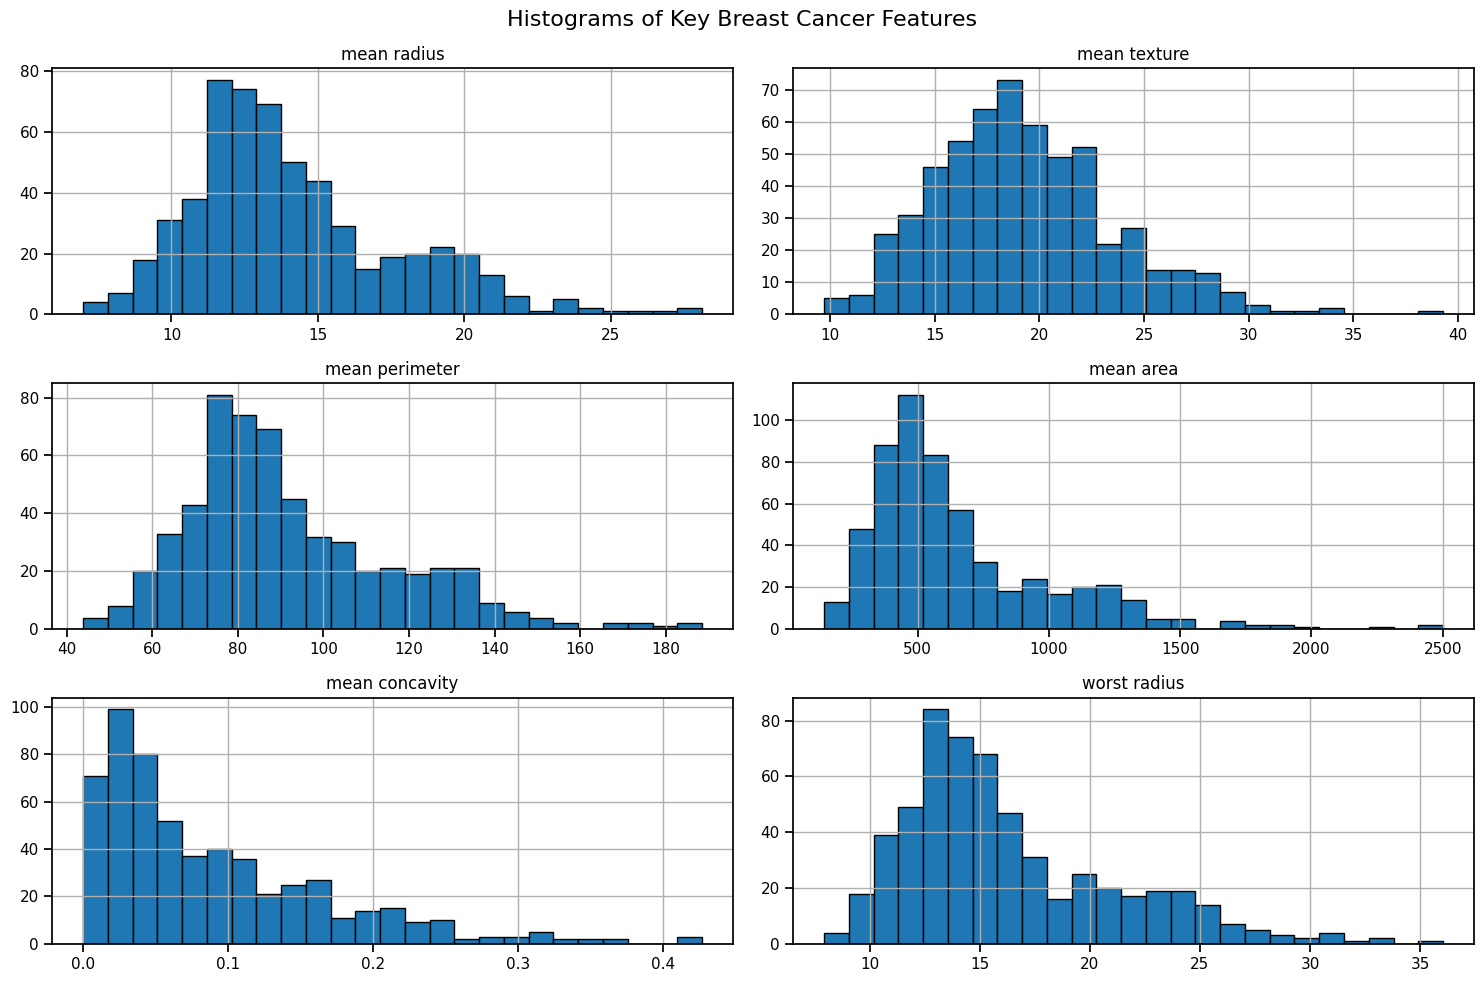

In [27]:

key_features = [
    "mean radius",
    "mean texture",
    "mean perimeter",
    "mean area",
    "mean concavity",
    "worst radius"
]

df[key_features].hist(figsize=(15, 10), bins=25, edgecolor="black")
plt.suptitle("Histograms of Key Breast Cancer Features", fontsize=16)
plt.tight_layout()
plt.show()


### 1.6 Box Plots for Key Features

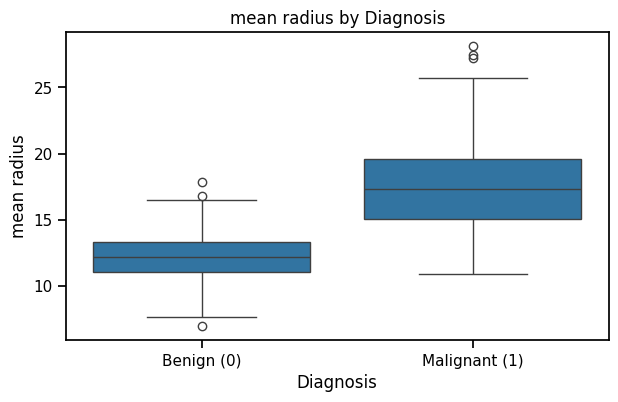

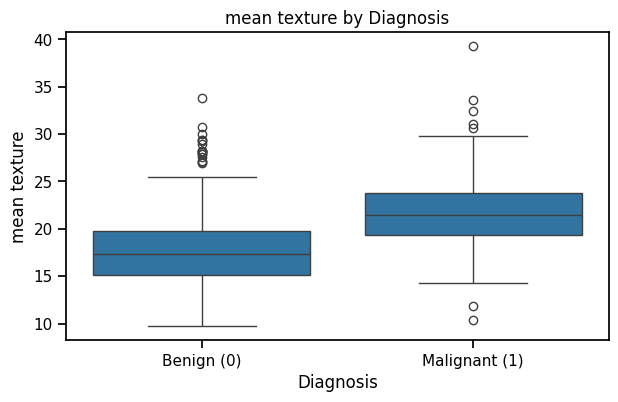

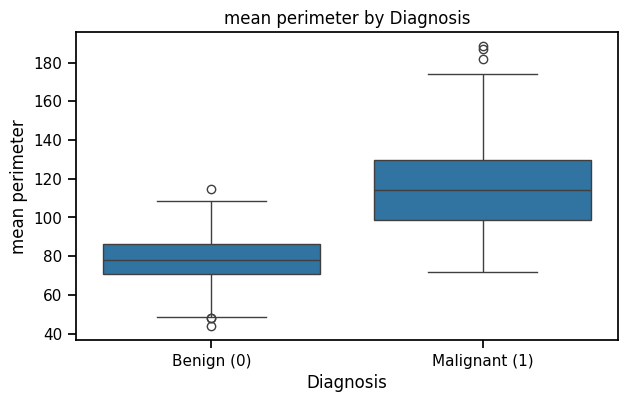

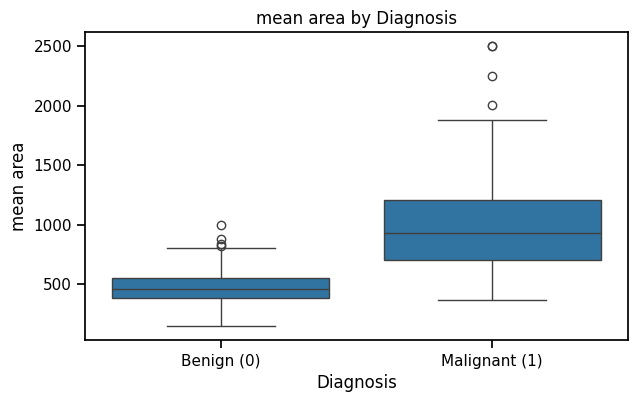

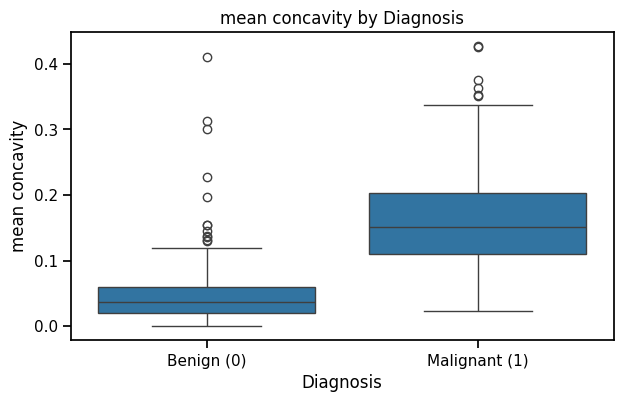

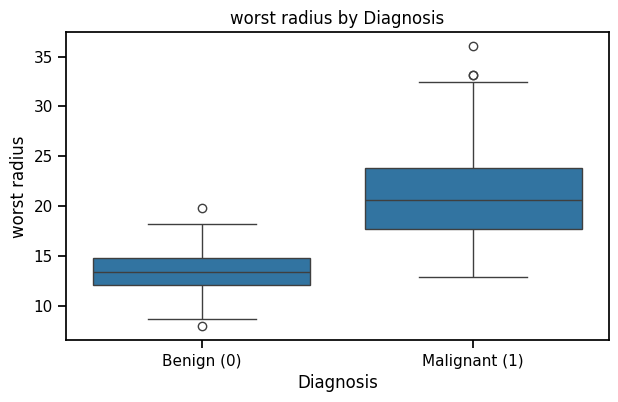

In [28]:

for feature in key_features:
    plt.figure(figsize=(7, 4))
    sns.boxplot(data=df, x="Outcome", y=feature)
    plt.xticks([0, 1], ["Benign (0)", "Malignant (1)"])
    plt.title(f"{feature} by Diagnosis")
    plt.xlabel("Diagnosis")
    plt.ylabel(feature)
    plt.show()



**Interpretation:**  
Several size- and shape-related features show visibly different distributions between benign and malignant cases. Malignant tumors tend to have larger values for features such as radius, perimeter, area and concavity.


### 1.7 Correlation Heatmap

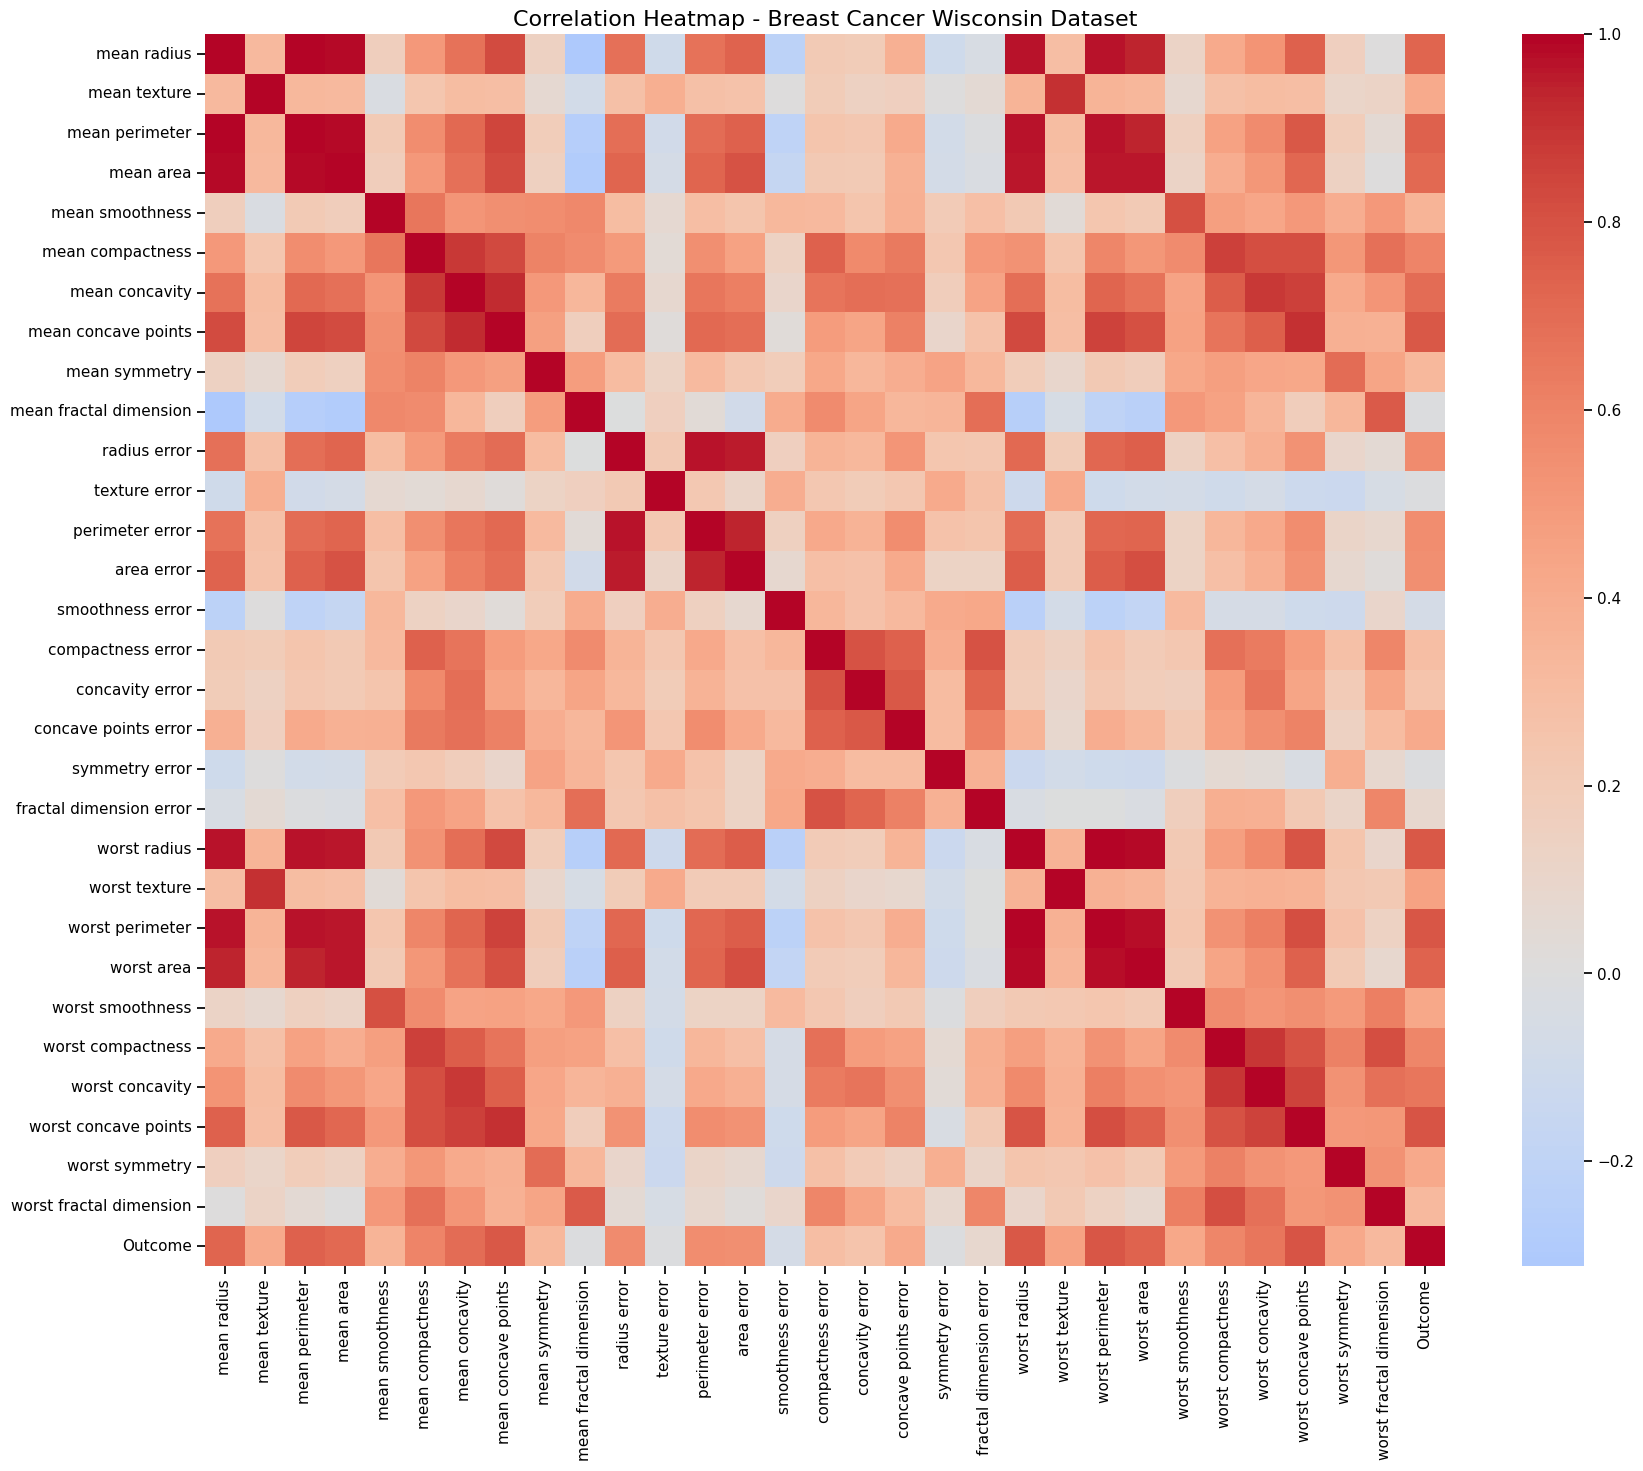

In [29]:

plt.figure(figsize=(20, 16))
corr_matrix = df.corr(numeric_only=True)
sns.heatmap(corr_matrix, cmap="coolwarm", center=0, square=False)
plt.title("Correlation Heatmap - Breast Cancer Wisconsin Dataset", fontsize=16)
plt.show()



**Interpretation:**  
Many geometric measurements are strongly correlated with one another, especially radius, perimeter and area features. Logistic regression can still work with correlated predictors, although strong multicollinearity can make individual coefficients less stable. Regularization helps control this.


### 1.8 Class Distribution

Class counts:
           Class  Count  Percentage
0     Benign (0)    357       62.74
1  Malignant (1)    212       37.26


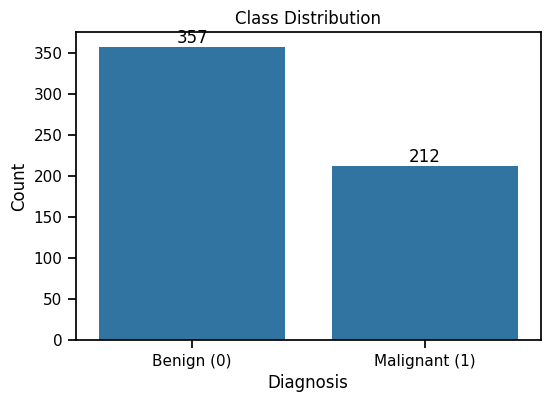

In [30]:

class_counts = df["Outcome"].value_counts().sort_index()
class_percentages = df["Outcome"].value_counts(normalize=True).sort_index() * 100

print("Class counts:")
print(pd.DataFrame({
    "Class": ["Benign (0)", "Malignant (1)"],
    "Count": class_counts.values,
    "Percentage": class_percentages.values.round(2)
}))

plt.figure(figsize=(6, 4))
ax = sns.countplot(data=df, x="Outcome")
plt.xticks([0, 1], ["Benign (0)", "Malignant (1)"])
plt.title("Class Distribution")
plt.xlabel("Diagnosis")
plt.ylabel("Count")

for container in ax.containers:
    ax.bar_label(container)

plt.show()



### Class-Imbalance Discussion
The dataset contains more benign than malignant samples (approximately **63% benign and 37% malignant**).  
This is a **moderate**, not extreme, imbalance.

Potential implications:
- Accuracy alone can be misleading because the majority class contributes more samples.
- Precision, recall and F1-score should be reported for both classes.
- For cancer diagnosis, **recall for the malignant class is particularly important** because a false negative means a malignant case is incorrectly predicted as benign.
- Stratified train/test splitting is used so both sets preserve approximately the same class ratio.


## Task 2 - Data Preprocessing

### 2.1 Prepare Features and Binary Target

In [31]:

X = df.drop(columns="Outcome")
y = df["Outcome"]

print("Target encoding:")
print("0 = Benign")
print("1 = Malignant")
print("\nTarget values:", sorted(y.unique()))


Target encoding:
0 = Benign
1 = Malignant

Target values: [np.int64(0), np.int64(1)]


### 2.2 Stratified 80/20 Train-Test Split

In [32]:

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

print("\nTraining class distribution:")
print((y_train.value_counts(normalize=True).sort_index() * 100).round(2))

print("\nTesting class distribution:")
print((y_test.value_counts(normalize=True).sort_index() * 100).round(2))


Training shape: (455, 30)
Testing shape: (114, 30)

Training class distribution:
Outcome
0    62.64
1    37.36
Name: proportion, dtype: float64

Testing class distribution:
Outcome
0    63.16
1    36.84
Name: proportion, dtype: float64


### 2.3 Handle Outliers Using Training-Set IQR Capping

In [33]:

# Compute IQR thresholds ONLY from training data to avoid data leakage.
Q1_train = X_train.quantile(0.25)
Q3_train = X_train.quantile(0.75)
IQR_train = Q3_train - Q1_train

train_lower = Q1_train - 1.5 * IQR_train
train_upper = Q3_train + 1.5 * IQR_train

# Apply the same training-derived limits to both training and test data.
X_train_capped = X_train.clip(lower=train_lower, upper=train_upper, axis=1)
X_test_capped = X_test.clip(lower=train_lower, upper=train_upper, axis=1)

print("IQR capping completed.")
print("Training data shape:", X_train_capped.shape)
print("Testing data shape:", X_test_capped.shape)


IQR capping completed.
Training data shape: (455, 30)
Testing data shape: (114, 30)


### 2.4 Standardize Features

In [34]:

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_capped)
X_test_scaled = scaler.transform(X_test_capped)

print("Training feature mean after scaling (approx.):",
      np.round(X_train_scaled.mean(axis=0).mean(), 6))
print("Training feature std after scaling (approx.):",
      np.round(X_train_scaled.std(axis=0).mean(), 6))


Training feature mean after scaling (approx.): 0.0
Training feature std after scaling (approx.): 1.0



**Why standardization?**  
Logistic regression estimates coefficients using numerical optimization and is affected by differences in feature scale. Standardization gives each feature approximately zero mean and unit variance, allowing the regularization penalty and coefficients to operate on comparable scales.


## Task 3 - Logistic Regression Training and Evaluation

### 3.1 Train Logistic Regression Model

In [35]:

model = LogisticRegression(
    max_iter=5000,
    random_state=RANDOM_STATE
)

model.fit(X_train_scaled, y_train)

print("model trained successfully.")


model trained successfully.


### 3.2 Predictions

In [36]:

y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

print("Number of test predictions:", len(y_pred))


Number of test predictions: 114


### 3.3 Accuracy, Precision, Recall and F1-Score

In [37]:

accuracy = accuracy_score(y_test, y_pred)
malignant_precision = precision_score(y_test, y_pred, pos_label=1)
malignant_recall = recall_score(y_test, y_pred, pos_label=1)
malignant_f1 = f1_score(y_test, y_pred, pos_label=1)

print(f"Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Malignant-class Precision: {malignant_precision:.4f}")
print(f"Malignant-class Recall:    {malignant_recall:.4f}")
print(f"Malignant-class F1-score:  {malignant_f1:.4f}")

print("\nClassification Report (both classes):")
print(classification_report(
    y_test,
    y_pred,
    target_names=["Benign (0)", "Malignant (1)"],
    digits=4
))


Accuracy: 0.9649 (96.49%)
Malignant-class Precision: 0.9750
Malignant-class Recall:    0.9286
Malignant-class F1-score:  0.9512

Classification Report (both classes):
               precision    recall  f1-score   support

   Benign (0)     0.9595    0.9861    0.9726        72
Malignant (1)     0.9750    0.9286    0.9512        42

     accuracy                         0.9649       114
    macro avg     0.9672    0.9573    0.9619       114
 weighted avg     0.9652    0.9649    0.9647       114



### 3.4 Confusion Matrix

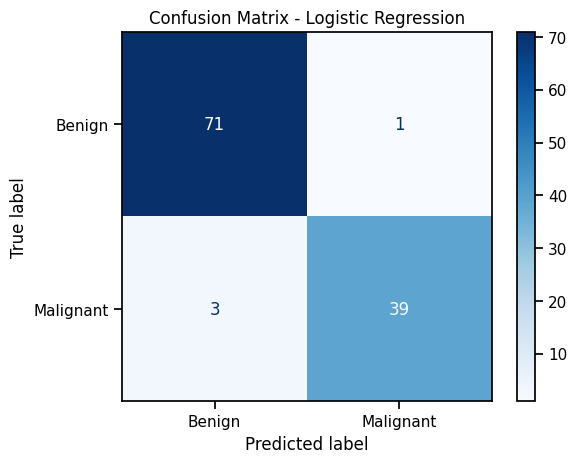

True Negatives (Benign correctly identified): 71
False Positives (Benign predicted Malignant): 1
False Negatives (Malignant predicted Benign): 3
True Positives (Malignant correctly identified): 39


In [38]:

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Benign", "Malignant"]
)
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

tn, fp, fn, tp = cm.ravel()

print("True Negatives (Benign correctly identified):", tn)
print("False Positives (Benign predicted Malignant):", fp)
print("False Negatives (Malignant predicted Benign):", fn)
print("True Positives (Malignant correctly identified):", tp)



### Medical Interpretation of the Confusion Matrix
- **True Positive:** malignant patient correctly detected.
- **True Negative:** benign patient correctly identified.
- **False Positive:** benign patient incorrectly flagged as malignant. This may lead to unnecessary anxiety or additional testing.
- **False Negative:** malignant patient incorrectly classified as benign. This is usually the most serious error because diagnosis and treatment may be delayed.

Therefore, malignant-class **recall/sensitivity** is especially important in this medical diagnosis problem.


### 3.5 ROC Curve and AUC

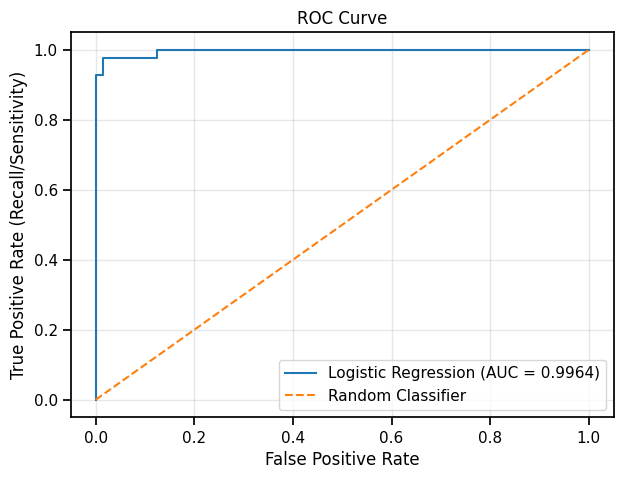

AUC Score: 0.9964


In [39]:

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {auc_score:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall/Sensitivity)")
plt.title("ROC Curve")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(f"AUC Score: {auc_score:.4f}")



### Final Result Interpretation
With `random_state = 42`, the model should achieve roughly **96% accuracy** and an **AUC close to 1.0**.

Interpretation:
- High accuracy indicates that most test samples are correctly classified.
- High precision for the malignant class means that most patients predicted as malignant are actually malignant.
- High malignant recall means that most true cancer cases are successfully detected.
- The F1-score balances malignant precision and recall.
- An AUC close to 1 indicates excellent ability to rank malignant cases above benign cases across different classification thresholds.
- In a medical setting, the most important remaining concern is the number of **false negatives**, because failing to identify a malignant tumor can have serious consequences.

A model with strong overall accuracy should therefore **not** be judged only by accuracy; malignant recall, the confusion matrix and ROC-AUC must also be considered.


## Optional - Regularization and Model Interpretation

### Compare L1 and L2 Regularization

In [40]:

regularization_results = []

for penalty, solver in [("l1", "liblinear"), ("l2", "liblinear")]:
    reg_model = LogisticRegression(
        penalty=penalty,
        solver=solver,
        C=1.0,
        max_iter=5000,
        random_state=RANDOM_STATE
    )
    reg_model.fit(X_train_scaled, y_train)
    reg_pred = reg_model.predict(X_test_scaled)
    reg_prob = reg_model.predict_proba(X_test_scaled)[:, 1]

    regularization_results.append({
        "Penalty": penalty.upper(),
        "Accuracy": accuracy_score(y_test, reg_pred),
        "Malignant Recall": recall_score(y_test, reg_pred, pos_label=1),
        "F1": f1_score(y_test, reg_pred, pos_label=1),
        "AUC": roc_auc_score(y_test, reg_prob)
    })

display(pd.DataFrame(regularization_results).round(4))


,Penalty,Accuracy,Malignant Recall,F1,AUC
0,L1,0.9737,0.9524,0.9639,0.9967
1,L2,0.9737,0.9524,0.9639,0.9964



**Regularization interpretation:**  
- **L2** shrinks coefficients toward zero and is the default logistic-regression penalty.
- **L1** can drive some coefficients exactly to zero, effectively performing feature selection.
- Regularization helps reduce overfitting and can make a model more stable when predictors are correlated.


### Interpret Logistic Regression Coefficients

In [41]:

coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

coef_df["Absolute Coefficient"] = coef_df["Coefficient"].abs()
coef_df = coef_df.sort_values("Absolute Coefficient", ascending=False)

print("Top 10 most influential standardized features:")
display(coef_df.head(10))

print("\nTop features increasing predicted malignant probability:")
display(
    coef_df.sort_values("Coefficient", ascending=False)
           [["Feature", "Coefficient"]]
           .head(10)
)

print("\nTop features decreasing predicted malignant probability:")
display(
    coef_df.sort_values("Coefficient", ascending=True)
           [["Feature", "Coefficient"]]
           .head(10)
)


Top 10 most influential standardized features:


,Feature,Coefficient,Absolute Coefficient
21,worst texture,1.464648,1.464648
13,area error,1.158545,1.158545
28,worst symmetry,1.050379,1.050379
15,compactness error,-1.018275,1.018275
7,mean concave points,0.906850,0.906850
10,radius error,0.874389,0.874389
26,worst concavity,0.835842,0.835842
23,worst area,0.794356,0.794356
6,mean concavity,0.749805,0.749805
19,fractal dimension error,-0.700057,0.700057



Top features increasing predicted malignant probability:


,Feature,Coefficient
21,worst texture,1.464648
13,area error,1.158545
28,worst symmetry,1.050379
7,mean concave points,0.906850
10,radius error,0.874389
26,worst concavity,0.835842
23,worst area,0.794356
6,mean concavity,0.749805
20,worst radius,0.694834
1,mean texture,0.643111



Top features decreasing predicted malignant probability:


,Feature,Coefficient
15,compactness error,-1.018275
19,fractal dimension error,-0.700057
5,mean compactness,-0.464254
11,texture error,-0.395904
18,symmetry error,-0.341745
8,mean symmetry,-0.181149
14,smoothness error,-0.141946
25,worst compactness,-0.087022
9,mean fractal dimension,0.051468
29,worst fractal dimension,0.055709



**Coefficient interpretation:**  
Because all predictors were standardized, coefficient magnitudes are more directly comparable.  
- A **positive coefficient** increases the model's estimated probability of malignancy.
- A **negative coefficient** decreases the estimated probability of malignancy.
- Larger absolute coefficients have a stronger effect on the model's log-odds prediction, although correlated features mean coefficients should not automatically be interpreted as causal effects.



## Conclusion
A complete logistic-regression pipeline was implemented for the Breast Cancer Wisconsin (Diagnostic) dataset. The workflow included:
- exploratory analysis and summary statistics,
- missing-value and duplicate checks,
- IQR-based outlier detection and capping,
- visual analysis,
- stratified train/test splitting,
- standardization,
- logistic regression training,
- accuracy, precision, recall, F1, confusion matrix, ROC and AUC evaluation,
- medical interpretation of false positives and false negatives,
- and optional regularization/coefficient interpretation.

The key medical takeaway is that **malignant recall (sensitivity)** and the number of **false negatives** deserve special attention rather than relying on accuracy alone.
